# CGS410 — Probing & Analysis
**Do Case Markers Reduce Contextual Encoding of Syntactic Role in LLMs?**

Archit Rahalkar (240172) · Taran Mohta (241095)

---

**Inputs:** embeddings + metadata from `02_embeddings.ipynb` for English, Hindi, and Turkish

**This notebook:**
1. Logistic regression probes per layer × language → probe accuracy curves
2. Mean cosine distance between subject/object centroids per lemma, per layer
3. Cross-language comparison plots
4. Per-lemma breakdown (which lemmas drive the effect)
5. Export result tables for write-up


## 0 · Install

In [1]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn

## 1 · Config

In [ ]:
from pathlib import Path

OUT_DIR  = Path("outputs")
FIG_DIR  = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

N_LAYERS    = 13
LAYER_NAMES = ["Emb"] + [str(i) for i in range(1, 13)]
RANDOM_SEED = 42

PROBE_CV_FOLDS  = 5
PROBE_MAX_ITER  = 1000
PROBE_C         = 1.0

LANG_COLORS = {"English": "#2196F3", "Hindi": "#FF5722", "Turkish": "#4CAF50"}

print("Config ready.")

Config ready.


## 2 · Load embeddings and metadata

In [ ]:
import numpy as np
import pandas as pd

en_embeddings = np.load(OUT_DIR / "en_embeddings.npz")["embeddings"]
hi_embeddings = np.load(OUT_DIR / "hi_embeddings.npz")["embeddings"]
tr_embeddings = np.load(OUT_DIR / "tr_embeddings.npz")["embeddings"]
en_meta = pd.read_csv(OUT_DIR / "en_meta.csv")
hi_meta = pd.read_csv(OUT_DIR / "hi_meta.csv")
tr_meta = pd.read_csv(OUT_DIR / "tr_meta.csv")

def drop_zero_rows(emb, meta):
    keep = ~(emb == 0).all(axis=(1, 2))
    n_dropped = (~keep).sum()
    if n_dropped:
        print(f"  Dropping {n_dropped} zero-embedding (truncated) rows.")
    return emb[keep], meta[keep].reset_index(drop=True)

en_embeddings, en_meta = drop_zero_rows(en_embeddings, en_meta)
hi_embeddings, hi_meta = drop_zero_rows(hi_embeddings, hi_meta)
tr_embeddings, tr_meta = drop_zero_rows(tr_embeddings, tr_meta)

en_labels = (en_meta["role"] == "subject").astype(int).values
hi_labels = (hi_meta["role"] == "subject").astype(int).values
tr_labels = (tr_meta["role"] == "subject").astype(int).values

for lang, emb, meta in [("English", en_embeddings, en_meta),
                         ("Hindi",   hi_embeddings, hi_meta),
                         ("Turkish", tr_embeddings, tr_meta)]:
    print(f"[{lang}] embeddings: {emb.shape} | "
          f"subject: {(meta['role']=='subject').sum():,} | "
          f"object: {(meta['role']=='object').sum():,}")

[English] embeddings: (3433, 13, 768) | subject: 1,717 | object: 1,716
[Hindi] embeddings: (3433, 13, 768) | subject: 1,716 | object: 1,717
[Turkish] embeddings: (3434, 13, 768) | subject: 1,717 | object: 1,717


## 3 · Logistic regression probes

For each of the 13 layers we train a logistic regression probe to predict
syntactic role (subject vs. object) from noun token embeddings.

We use **stratified 5-fold cross-validation** to produce robust accuracy estimates
while preserving class balance across folds.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from tqdm.auto import tqdm

def probe_all_layers(
    embeddings: np.ndarray,
    labels: np.ndarray,
    n_layers: int = 13,
    cv_folds: int = 5,
) -> pd.DataFrame:
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            C=PROBE_C,
            max_iter=PROBE_MAX_ITER,
            solver="lbfgs",
            random_state=RANDOM_SEED,
        )),
    ])

    rows = []
    for layer in tqdm(range(n_layers), desc="Layers"):
        X = embeddings[:, layer, :]
        scores = cross_val_score(
            pipe, X, labels, cv=cv,
            scoring="accuracy",
            n_jobs=-1,
        )
        rows.append({
            "layer"     : layer,
            "mean_acc"  : scores.mean(),
            "std_acc"   : scores.std(),
        })
    return pd.DataFrame(rows)


print("Running English probes ...")
en_probe_results = probe_all_layers(en_embeddings, en_labels)

print("Running Hindi probes ...")
hi_probe_results = probe_all_layers(hi_embeddings, hi_labels)

print("Running Turkish probes ...")
tr_probe_results = probe_all_layers(tr_embeddings, tr_labels)

print("\nDone. Peak probe accuracy:")
print(f"  English layer {en_probe_results['mean_acc'].idxmax()} : "
      f"{en_probe_results['mean_acc'].max():.4f}")
print(f"  Hindi   layer {hi_probe_results['mean_acc'].idxmax()} : "
      f"{hi_probe_results['mean_acc'].max():.4f}")
print(f"  Turkish layer {tr_probe_results['mean_acc'].idxmax()} : "
      f"{tr_probe_results['mean_acc'].max():.4f}")

c:\Users\asus\Desktop\cgsproject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running English probes ...


Layers: 100%|██████████| 13/13 [00:20<00:00,  1.55s/it]


Running Hindi probes ...


Layers: 100%|██████████| 13/13 [00:25<00:00,  1.95s/it]


Running Turkish probes ...


Layers: 100%|██████████| 13/13 [00:22<00:00,  1.73s/it]


Done. Peak probe accuracy:
  English layer 8 : 0.9502
  Hindi   layer 9 : 0.8223
  Turkish layer 11 : 0.8180


In [ ]:
comparison = pd.DataFrame({
    "layer"         : en_probe_results["layer"],
    "layer_name"    : LAYER_NAMES,
    "en_acc"        : en_probe_results["mean_acc"].round(4),
    "en_acc_std"    : en_probe_results["std_acc"].round(4),
    "hi_acc"        : hi_probe_results["mean_acc"].round(4),
    "hi_acc_std"    : hi_probe_results["std_acc"].round(4),
    "tr_acc"        : tr_probe_results["mean_acc"].round(4),
    "tr_acc_std"    : tr_probe_results["std_acc"].round(4),
    "diff_en_minus_hi": (en_probe_results["mean_acc"] - hi_probe_results["mean_acc"]).round(4),
    "diff_en_minus_tr": (en_probe_results["mean_acc"] - tr_probe_results["mean_acc"]).round(4),
})
display(comparison)

,layer,layer_name,en_acc,en_acc_std,hi_acc,hi_acc_std,tr_acc,tr_acc_std,diff_en_minus_hi,diff_en_minus_tr
0,0,Emb,0.6318,0.0138,0.6420,0.0249,0.7062,0.0122,-0.0102,-0.0744
1,1,1,0.6831,0.0160,0.6840,0.0309,0.7050,0.0134,-0.0009,-0.0219
2,2,2,0.7795,0.0105,0.7070,0.0141,0.7167,0.0074,0.0725,0.0628
3,3,3,0.8567,0.0092,0.7568,0.0204,0.7466,0.0129,0.0999,0.1100
4,4,4,0.8692,0.0086,0.7687,0.0224,0.7522,0.0177,0.1005,0.1170
5,5,5,0.9190,0.0083,0.7690,0.0266,0.7778,0.0054,0.1500,0.1412
6,6,6,0.9315,0.0051,0.8025,0.0151,0.7944,0.0050,0.1290,0.1371
7,7,7,0.9403,0.0049,0.8118,0.0141,0.8037,0.0074,0.1285,0.1366
8,8,8,0.9502,0.0081,0.8156,0.0132,0.8154,0.0134,0.1346,0.1348
9,9,9,0.9438,0.0012,0.8223,0.0148,0.8125,0.0036,0.1215,0.1313


## 4 · Cosine distance analysis

For each lemma appearing in both roles, compute the **centroid** of its subject
embeddings and the centroid of its object embeddings, then measure cosine
distance between them. We average this across lemmas at each layer.

Greater mean distance indicates greater role-based separation in embedding space.

In [ ]:
from sklearn.metrics.pairwise import cosine_distances

def mean_cosine_distance_by_layer(
    embeddings: np.ndarray,
    meta: pd.DataFrame,
    n_layers: int = 13,
) -> pd.DataFrame:
    dual_lemmas = (
        meta.groupby("lemma")["role"]
            .apply(lambda r: set(r))
            .pipe(lambda s: s[s.apply(lambda x: {"subject", "object"}.issubset(x))]
                            .index.tolist())
    )

    rows = []
    for layer in range(n_layers):
        X = embeddings[:, layer, :]
        distances = []

        for lemma in dual_lemmas:
            subj_idx = meta.index[(meta["lemma"] == lemma) & (meta["role"] == "subject")]
            obj_idx  = meta.index[(meta["lemma"] == lemma) & (meta["role"] == "object")]

            subj_centroid = X[subj_idx].mean(axis=0, keepdims=True)
            obj_centroid  = X[obj_idx].mean(axis=0, keepdims=True)

            dist = cosine_distances(subj_centroid, obj_centroid)[0, 0]
            distances.append(dist)

        distances = np.array(distances)
        rows.append({
            "layer"            : layer,
            "mean_cosine_dist" : distances.mean(),
            "std_cosine_dist"  : distances.std(),
            "n_lemmas"         : len(dual_lemmas),
        })

    return pd.DataFrame(rows)


print("Computing English cosine distances ...")
en_cosine = mean_cosine_distance_by_layer(en_embeddings, en_meta)

print("Computing Hindi cosine distances ...")
hi_cosine = mean_cosine_distance_by_layer(hi_embeddings, hi_meta)

print("Computing Turkish cosine distances ...")
tr_cosine = mean_cosine_distance_by_layer(tr_embeddings, tr_meta)

print("\nPeak mean cosine distance:")
print(f"  English layer {en_cosine['mean_cosine_dist'].idxmax()} : "
      f"{en_cosine['mean_cosine_dist'].max():.4f}")
print(f"  Hindi   layer {hi_cosine['mean_cosine_dist'].idxmax()} : "
      f"{hi_cosine['mean_cosine_dist'].max():.4f}")
print(f"  Turkish layer {tr_cosine['mean_cosine_dist'].idxmax()} : "
      f"{tr_cosine['mean_cosine_dist'].max():.4f}")

Computing English cosine distances ...
Computing Hindi cosine distances ...
Computing Turkish cosine distances ...

Peak mean cosine distance:
  English layer 12 : 0.3025
  Hindi   layer 12 : 0.1849
  Turkish layer 0 : 0.2390


## 5 · Plots

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", font_scale=1.15)
LAYER_TICKS = list(range(13))
LAYER_LABELS = LAYER_NAMES

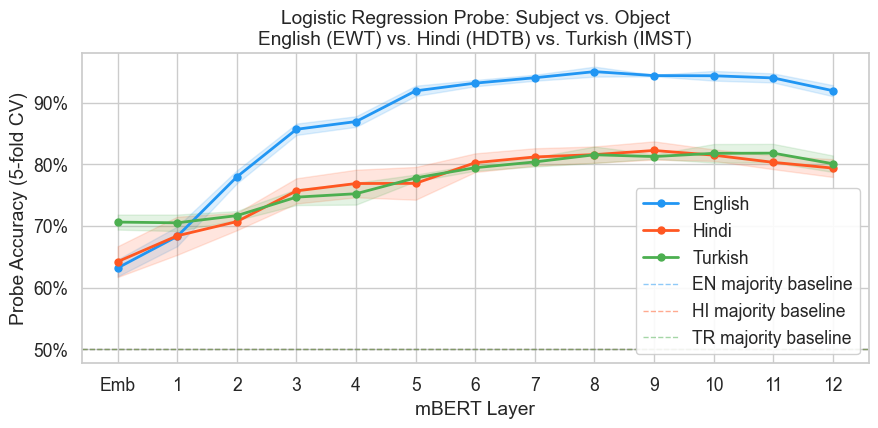

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for lang, res, color in [
    ("English", en_probe_results, LANG_COLORS["English"]),
    ("Hindi",   hi_probe_results, LANG_COLORS["Hindi"]),
    ("Turkish", tr_probe_results, LANG_COLORS["Turkish"]),
]:
    ax.plot(res["layer"], res["mean_acc"], marker="o", label=lang,
            color=color, linewidth=2, markersize=5)
    ax.fill_between(
        res["layer"],
        res["mean_acc"] - res["std_acc"],
        res["mean_acc"] + res["std_acc"],
        alpha=0.15, color=color
    )

en_majority = max(en_labels.mean(), 1 - en_labels.mean())
hi_majority = max(hi_labels.mean(), 1 - hi_labels.mean())
tr_majority = max(tr_labels.mean(), 1 - tr_labels.mean())
ax.axhline(en_majority, color=LANG_COLORS["English"], linestyle="--",
           linewidth=1, alpha=0.5, label="EN majority baseline")
ax.axhline(hi_majority, color=LANG_COLORS["Hindi"],   linestyle="--",
           linewidth=1, alpha=0.5, label="HI majority baseline")
ax.axhline(tr_majority, color=LANG_COLORS["Turkish"], linestyle="--",
           linewidth=1, alpha=0.5, label="TR majority baseline")

ax.set_xticks(LAYER_TICKS)
ax.set_xticklabels(LAYER_LABELS)
ax.set_xlabel("mBERT Layer")
ax.set_ylabel("Probe Accuracy (5-fold CV)")
ax.set_title("Logistic Regression Probe: Subject vs. Object\nEnglish (EWT) vs. Hindi (HDTB) vs. Turkish (IMST)")
ax.legend(framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.savefig(FIG_DIR / "probe_accuracy.pdf", dpi=300)
plt.savefig(FIG_DIR / "probe_accuracy.png", dpi=150)
plt.show()

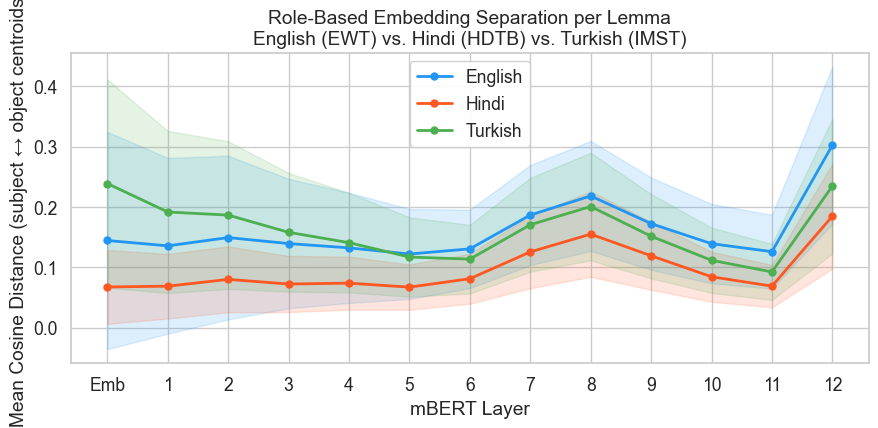

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for lang, res, color in [
    ("English", en_cosine, LANG_COLORS["English"]),
    ("Hindi",   hi_cosine, LANG_COLORS["Hindi"]),
    ("Turkish", tr_cosine, LANG_COLORS["Turkish"]),
]:
    ax.plot(res["layer"], res["mean_cosine_dist"], marker="o", label=lang,
            color=color, linewidth=2, markersize=5)
    ax.fill_between(
        res["layer"],
        res["mean_cosine_dist"] - res["std_cosine_dist"],
        res["mean_cosine_dist"] + res["std_cosine_dist"],
        alpha=0.15, color=color
    )

ax.set_xticks(LAYER_TICKS)
ax.set_xticklabels(LAYER_LABELS)
ax.set_xlabel("mBERT Layer")
ax.set_ylabel("Mean Cosine Distance (subject ↔ object centroids)")
ax.set_title("Role-Based Embedding Separation per Lemma\nEnglish (EWT) vs. Hindi (HDTB) vs. Turkish (IMST)")
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / "cosine_distance.pdf", dpi=300)
plt.savefig(FIG_DIR / "cosine_distance.png", dpi=150)
plt.show()

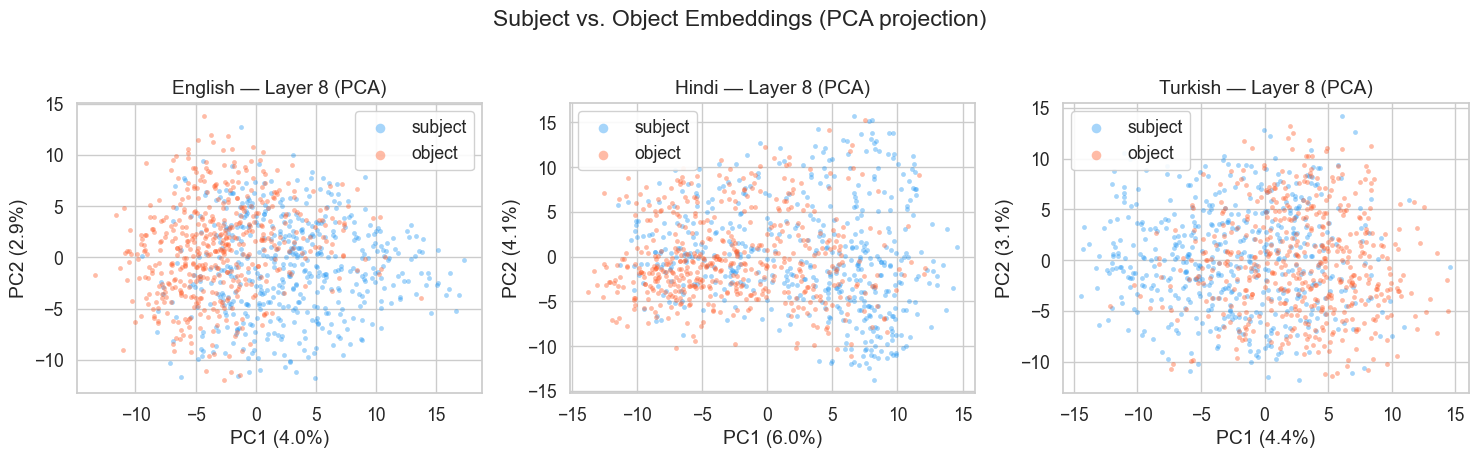

In [ ]:
INSPECT_LAYER = 8

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, lang, emb, meta in [
    (axes[0], "English", en_embeddings, en_meta),
    (axes[1], "Hindi",   hi_embeddings, hi_meta),
    (axes[2], "Turkish", tr_embeddings, tr_meta),
]:
    X  = emb[:, INSPECT_LAYER, :]
    y  = (meta["role"] == "subject").astype(int)

    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X_2d = pca.fit_transform(X_scaled)

    MAX_POINTS = 1000
    rng = np.random.default_rng(RANDOM_SEED)

    subj_indices = np.where(y.values == 1)[0]
    obj_indices  = np.where(y.values == 0)[0]
    points_per_class = min(MAX_POINTS // 2, len(subj_indices), len(obj_indices))

    subj_idx = rng.choice(subj_indices, size=points_per_class, replace=False)
    obj_idx  = rng.choice(obj_indices, size=points_per_class, replace=False)
    idx = np.concatenate([subj_idx, obj_idx])

    for role_val, label_str, c in [(1, "subject", "#2196F3"), (0, "object", "#FF5722")]:
        mask = y.values[idx] == role_val
        ax.scatter(
            X_2d[idx][mask, 0],
            X_2d[idx][mask, 1],
            c=c,
            label=label_str,
            alpha=0.4,
            s=12,
            linewidths=0
        )

    var_explained = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}%)")
    ax.set_title(f"{lang} — Layer {INSPECT_LAYER} (PCA)")
    ax.legend(markerscale=2, framealpha=0.9)

plt.suptitle("Subject vs. Object Embeddings (PCA projection)", y=1.02)
plt.tight_layout()

plt.savefig(FIG_DIR / f"pca_layer{INSPECT_LAYER}.png", dpi=150, bbox_inches="tight")
plt.savefig(FIG_DIR / f"pca_layer{INSPECT_LAYER}.pdf", dpi=300, bbox_inches="tight")

plt.show()

## 5b · Quantify PCA Overlap (Cluster Separation Quality)

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

INSPECT_LAYER = 8  # Same layer as PCA visualization

# Compute clustering quality metrics for each language
overlap_metrics = []

for lang, emb, meta, color in [
    ("English", en_embeddings, en_meta, LANG_COLORS["English"]),
    ("Hindi",   hi_embeddings, hi_meta, LANG_COLORS["Hindi"]),
    ("Turkish", tr_embeddings, tr_meta, LANG_COLORS["Turkish"]),
]:
    X = emb[:, INSPECT_LAYER, :]  # (N, 768)
    y = (meta["role"] == "subject").astype(int).values
    
    # Silhouette score: -1 to 1, higher is better (well-separated clusters)
    silhouette = silhouette_score(X, y)
    
    # Davies-Bouldin Index: lower is better (clusters well-separated)
    davies_bouldin = davies_bouldin_score(X, y)
    
    # Calinski-Harabasz Index: higher is better (clusters well-separated)
    calinski_harabasz = calinski_harabasz_score(X, y)
    
    overlap_metrics.append({
        "language": lang,
        "silhouette_score": silhouette,
        "davies_bouldin_index": davies_bouldin,
        "calinski_harabasz_index": calinski_harabasz,
    })

overlap_df = pd.DataFrame(overlap_metrics)
print(f"Cluster Separation Quality Metrics (Layer {INSPECT_LAYER}):")
print("=" * 80)
display(overlap_df.round(4))

print("\nInterpretation:")
print("  Silhouette Score       [-1, 1]:  >0.5 = good separation,  <0 = poor separation")
print("  Davies-Bouldin Index   [0, ∞]:   lower = better separation")
print("  Calinski-Harabasz Idx  [0, ∞]:   higher = better separation")


Cluster Separation Quality Metrics (Layer 8):


,language,silhouette_score,davies_bouldin_index,calinski_harabasz_index
0,English,0.0179,7.3334,63.3216
1,Hindi,0.0173,7.5253,59.8371
2,Turkish,0.0151,7.9983,52.9600



Interpretation:
  Silhouette Score       [-1, 1]:  >0.5 = good separation,  <0 = poor separation
  Davies-Bouldin Index   [0, ∞]:   lower = better separation
  Calinski-Harabasz Idx  [0, ∞]:   higher = better separation


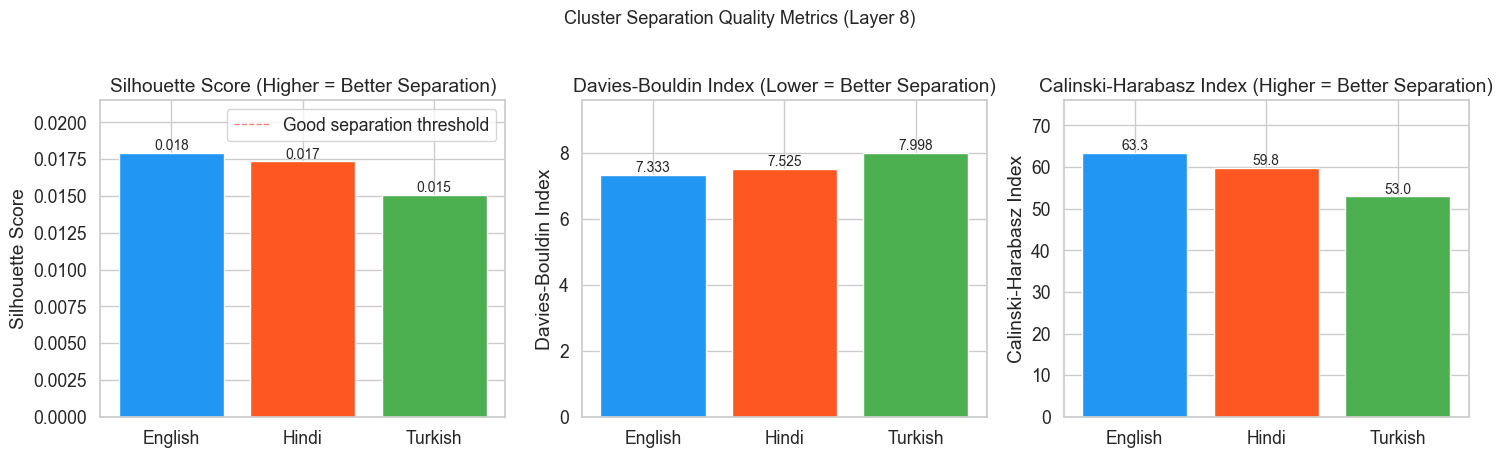


Saved to outputs/overlap_metrics_layer8.csv


In [19]:
# Visualize overlap metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Silhouette score (higher is better)
ax = axes[0]
bars = ax.bar(overlap_df["language"], overlap_df["silhouette_score"],
              color=[LANG_COLORS["English"], LANG_COLORS["Hindi"], LANG_COLORS["Turkish"]])
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score (Higher = Better Separation)")
ax.set_ylim(0, max(overlap_df["silhouette_score"]) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Good separation threshold")
ax.legend()

# Davies-Bouldin Index (lower is better)
ax = axes[1]
bars = ax.bar(overlap_df["language"], overlap_df["davies_bouldin_index"],
              color=[LANG_COLORS["English"], LANG_COLORS["Hindi"], LANG_COLORS["Turkish"]])
ax.set_ylabel("Davies-Bouldin Index")
ax.set_title("Davies-Bouldin Index (Lower = Better Separation)")
ax.set_ylim(0, max(overlap_df["davies_bouldin_index"]) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Calinski-Harabasz Index (higher is better)
ax = axes[2]
bars = ax.bar(overlap_df["language"], overlap_df["calinski_harabasz_index"],
              color=[LANG_COLORS["English"], LANG_COLORS["Hindi"], LANG_COLORS["Turkish"]])
ax.set_ylabel("Calinski-Harabasz Index")
ax.set_title("Calinski-Harabasz Index (Higher = Better Separation)")
ax.set_ylim(0, max(overlap_df["calinski_harabasz_index"]) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle(f"Cluster Separation Quality Metrics (Layer {INSPECT_LAYER})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / f"overlap_metrics_layer{INSPECT_LAYER}.png", dpi=150, bbox_inches="tight")
plt.show()

# Save metrics to CSV
overlap_df.to_csv(OUT_DIR / f"overlap_metrics_layer{INSPECT_LAYER}.csv", index=False)
print(f"\nSaved to outputs/overlap_metrics_layer{INSPECT_LAYER}.csv")


## 6 · Per-lemma breakdown

Which lemmas show the largest role-based separation, and does this differ across languages? Useful for qualitative discussion in the write-up.

In [ ]:
def per_lemma_cosine_dist(embeddings, meta, layer):
    X = embeddings[:, layer, :]
    rows = []
    for lemma, group in meta.groupby("lemma"):
        subj_idx = group.index[group["role"] == "subject"]
        obj_idx  = group.index[group["role"] == "object"]
        if len(subj_idx) == 0 or len(obj_idx) == 0:
            continue
        sc = X[subj_idx].mean(axis=0, keepdims=True)
        oc = X[obj_idx].mean(axis=0, keepdims=True)
        rows.append({
            "lemma"       : lemma,
            "subj_count"  : len(subj_idx),
            "obj_count"   : len(obj_idx),
            "cosine_dist" : cosine_distances(sc, oc)[0, 0],
        })
    return pd.DataFrame(rows).sort_values("cosine_dist", ascending=False)


INSPECT_LAYER = 8

en_lemma_dist = per_lemma_cosine_dist(en_embeddings, en_meta, INSPECT_LAYER)
hi_lemma_dist = per_lemma_cosine_dist(hi_embeddings, hi_meta, INSPECT_LAYER)
tr_lemma_dist = per_lemma_cosine_dist(tr_embeddings, tr_meta, INSPECT_LAYER)

print(f"English — top 10 lemmas by cosine distance (layer {INSPECT_LAYER}):")
display(en_lemma_dist.head(10))

print(f"\nHindi — top 10 lemmas by cosine distance (layer {INSPECT_LAYER}):")
display(hi_lemma_dist.head(10))

print(f"\nTurkish — top 10 lemmas by cosine distance (layer {INSPECT_LAYER}):")
display(tr_lemma_dist.head(10))

English — top 10 lemmas by cosine distance (layer 8):


,lemma,subj_count,obj_count,cosine_dist
363,section,1,1,0.512308
356,salad,2,1,0.487616
178,host,1,1,0.483166
311,portion,1,1,0.446266
140,expression,1,1,0.445116
384,star,1,4,0.435890
137,excerpt,1,1,0.429349
148,finger,1,1,0.428604
32,bill,3,2,0.426724
335,reason,2,1,0.421334



Hindi — top 10 lemmas by cosine distance (layer 8):


,lemma,subj_count,obj_count,cosine_dist
97,जगह,1,3,0.393494
22,आहार,1,1,0.389677
333,सहयोगी,1,1,0.346961
130,दर्द,1,1,0.342534
9,अली,1,1,0.335812
154,निर्माण,1,1,0.317921
135,दिन,1,1,0.309621
43,करार,1,1,0.308267
290,वजन,1,1,0.307940
80,गोली,1,4,0.300791



Turkish — top 10 lemmas by cosine distance (layer 8):


,lemma,subj_count,obj_count,cosine_dist
108,dizi,1,1,0.488181
67,bina,1,1,0.471346
52,bayan,1,1,0.443671
133,erke,1,1,0.441426
508,öfke,1,1,0.440686
126,ekonomi,1,1,0.420268
211,iklim,1,1,0.408977
99,deniz,2,2,0.403105
462,vali,1,1,0.401046
355,perde,1,1,0.398982


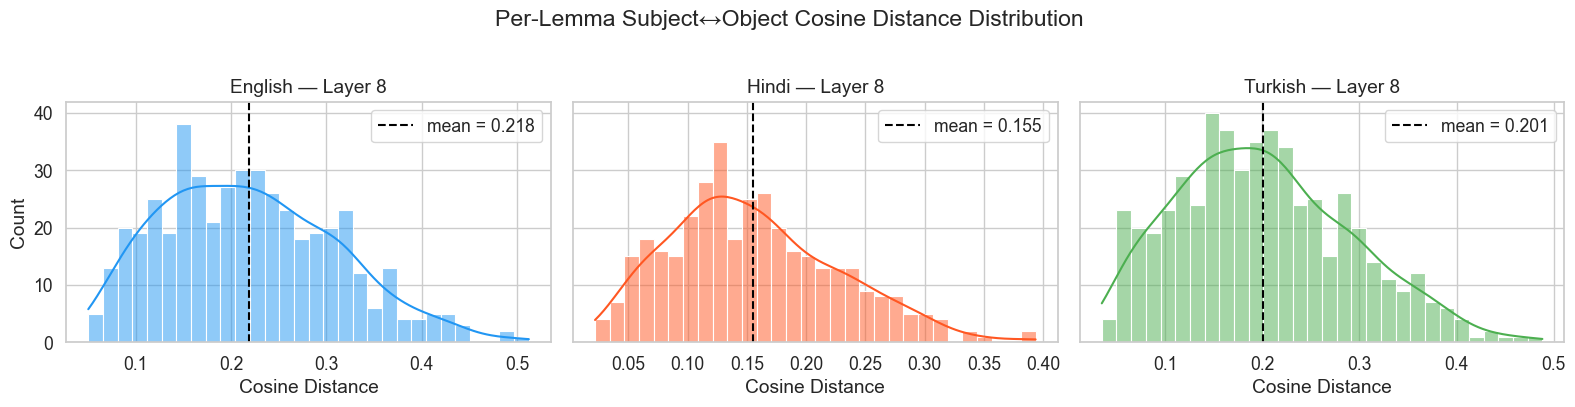

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, lang, dist_df, color in [
    (axes[0], "English", en_lemma_dist, LANG_COLORS["English"]),
    (axes[1], "Hindi",   hi_lemma_dist, LANG_COLORS["Hindi"]),
    (axes[2], "Turkish", tr_lemma_dist, LANG_COLORS["Turkish"]),
]:
    sns.histplot(dist_df["cosine_dist"], ax=ax, color=color, bins=30, kde=True)
    ax.axvline(dist_df["cosine_dist"].mean(), color="black",
               linestyle="--", linewidth=1.5, label=f"mean = {dist_df['cosine_dist'].mean():.3f}")
    ax.set_xlabel("Cosine Distance")
    ax.set_ylabel("Count")
    ax.set_title(f"{lang} — Layer {INSPECT_LAYER}")
    ax.legend()

plt.suptitle("Per-Lemma Subject↔Object Cosine Distance Distribution", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / f"lemma_dist_layer{INSPECT_LAYER}.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 · Statistical test

We test whether probe accuracy and mean cosine distance are significantly higher
for English than Hindi using a **paired permutation test** across the 5 CV folds.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def fold_accuracies(embeddings, labels, layer, cv_folds=5):
    X = embeddings[:, layer, :]
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=PROBE_C, max_iter=PROBE_MAX_ITER,
                                   solver="lbfgs", random_state=RANDOM_SEED)),
    ])
    from sklearn.model_selection import cross_val_score
    return cross_val_score(pipe, X, labels, cv=cv, scoring="accuracy")


def mann_whitney_test(a, b):
    from scipy.stats import mannwhitneyu
    diff = np.mean(a) - np.mean(b)
    statistic, p_value = mannwhitneyu(a, b, alternative='two-sided')
    return diff, statistic, p_value


peak_layer_en = int(en_probe_results["mean_acc"].idxmax())
peak_layer_hi = int(hi_probe_results["mean_acc"].idxmax())
peak_layer_tr = int(tr_probe_results["mean_acc"].idxmax())

print("=" * 60)
print("STATISTICAL TESTS (Mann-Whitney U)")
print("=" * 60)

en_folds = fold_accuracies(en_embeddings, en_labels, peak_layer_en)
hi_folds = fold_accuracies(hi_embeddings, hi_labels, peak_layer_hi)
tr_folds = fold_accuracies(tr_embeddings, tr_labels, peak_layer_tr)

print(f"\nEnglish vs Hindi (at layer {peak_layer_en}):")
obs_diff, u_stat, p_value = mann_whitney_test(en_folds, hi_folds)
print(f"  EN mean accuracy : {en_folds.mean():.4f} ± {en_folds.std():.4f}")
print(f"  HI mean accuracy : {hi_folds.mean():.4f} ± {hi_folds.std():.4f}")
print(f"  Observed diff    : {obs_diff:+.4f}")
print(f"  p-value (2-sided): {p_value:.4f}")
print(f"  → {'Significant' if p_value < 0.05 else 'Not significant'} at α=0.05")

print(f"\nEnglish vs Turkish (at layer {peak_layer_en}):")
obs_diff, u_stat, p_value = mann_whitney_test(en_folds, tr_folds)
print(f"  EN mean accuracy : {en_folds.mean():.4f} ± {en_folds.std():.4f}")
print(f"  TR mean accuracy : {tr_folds.mean():.4f} ± {tr_folds.std():.4f}")
print(f"  Observed diff    : {obs_diff:+.4f}")
print(f"  p-value (2-sided): {p_value:.4f}")
print(f"  → {'Significant' if p_value < 0.05 else 'Not significant'} at α=0.05")

print(f"\nHindi vs Turkish (at layer {peak_layer_hi}):")
obs_diff, u_stat, p_value = mann_whitney_test(hi_folds, tr_folds)
print(f"  HI mean accuracy : {hi_folds.mean():.4f} ± {hi_folds.std():.4f}")
print(f"  TR mean accuracy : {tr_folds.mean():.4f} ± {tr_folds.std():.4f}")
print(f"  Observed diff    : {obs_diff:+.4f}")
print(f"  p-value (2-sided): {p_value:.4f}")
print(f"  → {'Significant' if p_value < 0.05 else 'Not significant'} at α=0.05")
print("=" * 60)

STATISTICAL TESTS (Mann-Whitney U)

English vs Hindi (at layer 8):
  EN mean accuracy : 0.9502 ± 0.0081
  HI mean accuracy : 0.8223 ± 0.0148
  Observed diff    : +0.1279
  p-value (2-sided): 0.0079
  → Significant at α=0.05

English vs Turkish (at layer 8):
  EN mean accuracy : 0.9502 ± 0.0081
  TR mean accuracy : 0.8180 ± 0.0150
  Observed diff    : +0.1322
  p-value (2-sided): 0.0079
  → Significant at α=0.05

Hindi vs Turkish (at layer 9):
  HI mean accuracy : 0.8223 ± 0.0148
  TR mean accuracy : 0.8180 ± 0.0150
  Observed diff    : +0.0043
  p-value (2-sided): 0.7533
  → Not significant at α=0.05


## 8 · Export result tables

In [ ]:
comparison.to_csv(OUT_DIR / "probe_accuracy_by_layer.csv", index=False)

cosine_comparison = pd.DataFrame({
    "layer"            : en_cosine["layer"],
    "layer_name"       : LAYER_NAMES,
    "en_cosine_dist"   : en_cosine["mean_cosine_dist"].round(5),
    "en_cosine_std"    : en_cosine["std_cosine_dist"].round(5),
    "hi_cosine_dist"   : hi_cosine["mean_cosine_dist"].round(5),
    "hi_cosine_std"    : hi_cosine["std_cosine_dist"].round(5),
    "tr_cosine_dist"   : tr_cosine["mean_cosine_dist"].round(5),
    "tr_cosine_std"    : tr_cosine["std_cosine_dist"].round(5),
    "diff_en_minus_hi" : (en_cosine["mean_cosine_dist"] - hi_cosine["mean_cosine_dist"]).round(5),
    "diff_en_minus_tr" : (en_cosine["mean_cosine_dist"] - tr_cosine["mean_cosine_dist"]).round(5),
})
cosine_comparison.to_csv(OUT_DIR / "cosine_distance_by_layer.csv", index=False)

en_lemma_dist.to_csv(OUT_DIR / f"en_lemma_dist_layer{INSPECT_LAYER}.csv", index=False)
hi_lemma_dist.to_csv(OUT_DIR / f"hi_lemma_dist_layer{INSPECT_LAYER}.csv", index=False)
tr_lemma_dist.to_csv(OUT_DIR / f"tr_lemma_dist_layer{INSPECT_LAYER}.csv", index=False)

print("Saved to outputs/:")
for f in sorted(OUT_DIR.glob("*.csv")):
    print(f"  {f.name}")
print("\nFigures saved to figures/:")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}")

Saved to outputs/:
  cosine_distance_by_layer.csv
  en_balanced.csv
  en_filtered.csv
  en_lemma_dist_layer8.csv
  en_meta.csv
  en_tokens.csv
  hi_balanced.csv
  hi_filtered.csv
  hi_lemma_dist_layer8.csv
  hi_meta.csv
  hi_tokens.csv
  probe_accuracy_by_layer.csv
  tr_balanced.csv
  tr_filtered.csv
  tr_lemma_dist_layer8.csv
  tr_meta.csv
  tr_tokens.csv

Figures saved to figures/:
  cosine_distance.pdf
  cosine_distance.png
  lemma_dist_layer8.png
  pca_layer8.pdf
  pca_layer8.png
  probe_accuracy.pdf
  probe_accuracy.png
